In [1]:
import sys; sys.path.insert(0, ".")
import pandas as pd
import matplotlib.pyplot as plt

from constants import (
    ret_path,
)
from port_sort import (
    build_sml_panel,
    plot_sml_conditional,
    run_sml_fm_by_quintiles,
    print_latex_sml_fm_table,
)


In [2]:
# Build SML panel (daily return only) and load FF6 daily
beta_col = "Beta252d"
k_groups = 10

sml_panel = build_sml_panel(beta_col=beta_col)
ff6_daily = pd.read_csv(ret_path + "ff6_daily_returns.csv")


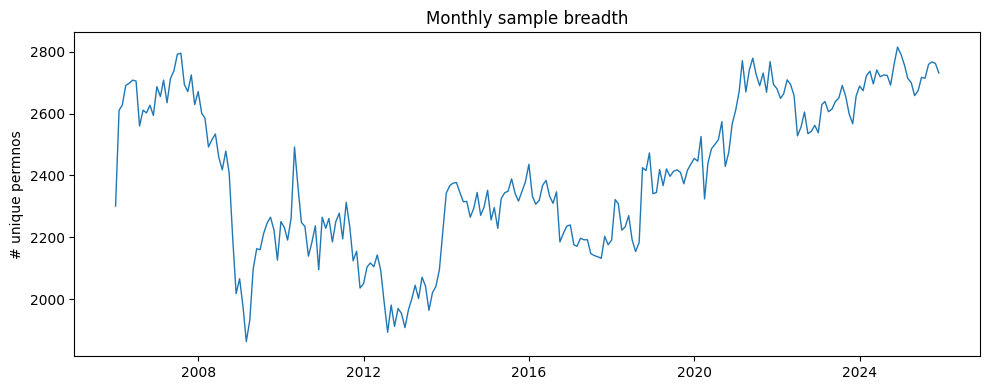

In [3]:
# Plot sample breadth: number of unique permnos per month
n_month = sml_panel.groupby("yyyymm")["permno"].nunique().reset_index(name="n_permno")
n_month["dt"] = pd.to_datetime(n_month["yyyymm"].astype(str), format="%Y%m")
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.plot(n_month["dt"], n_month["n_permno"], lw=1.0)
ax.set_xlabel("")
ax.set_ylabel("# unique permnos")
ax.set_title("Monthly sample breadth")
ax.grid(False)
plt.tight_layout()
plt.show()


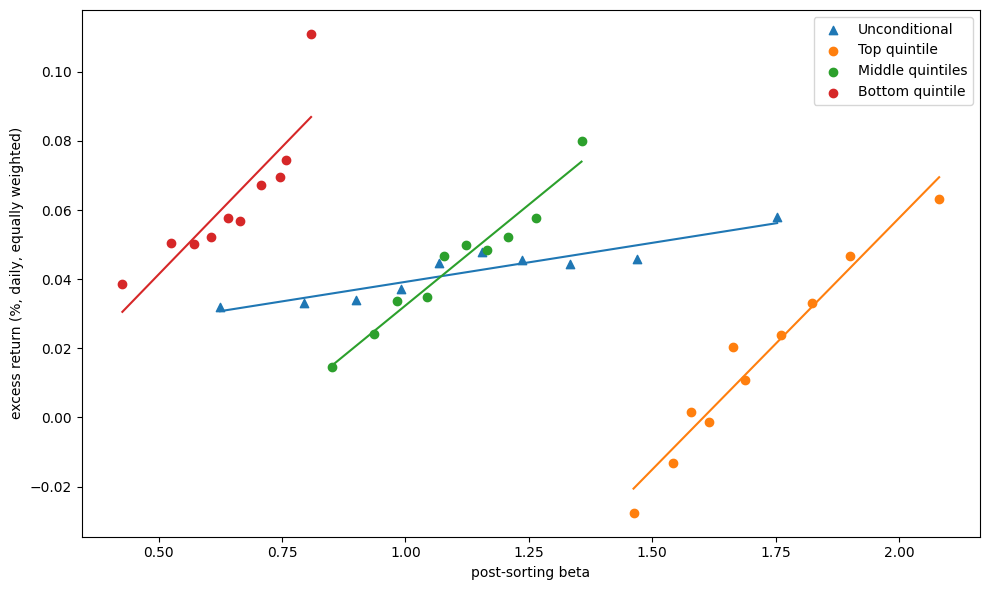

In [4]:
# Plot 1: conditional SML (EW)
plot_sml_conditional(
    sml_panel,
    ff6_daily,
    eqw=True,
    k_groups=k_groups,
    beta_col="beta_sort",
    low=0.2,
    high=0.8,
    save_filename="sml_ew_cond.pdf",
)


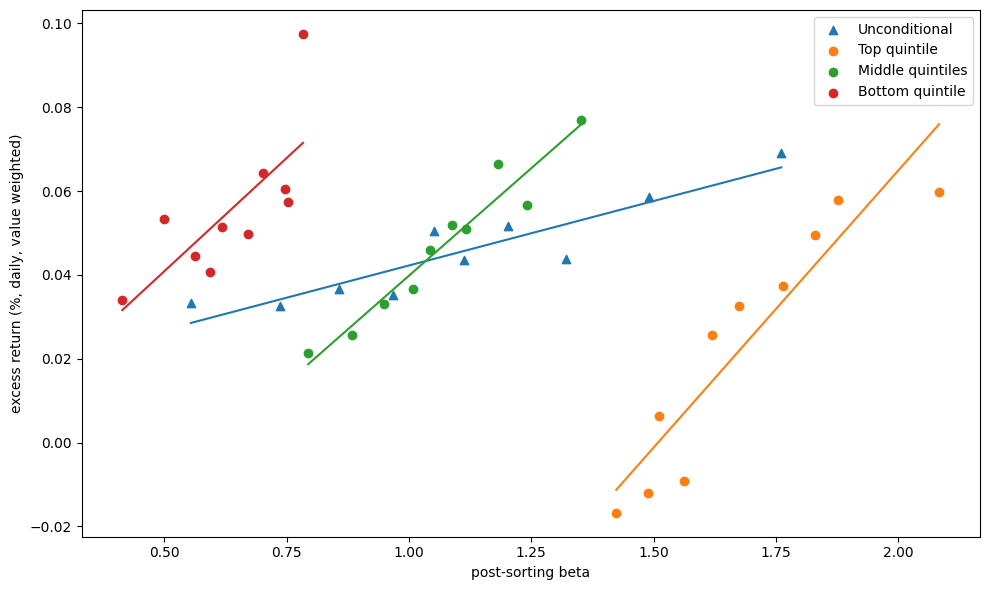

In [5]:
# Plot 2: conditional SML (VW)
plot_sml_conditional(
    sml_panel,
    ff6_daily,
    eqw=False,
    k_groups=k_groups,
    beta_col="beta_sort",
    low=0.2,
    high=0.8,
    save_filename="sml_vw_cond.pdf",
)


In [6]:
# FM regressions by news quintiles (EW): full/top/middle/bottom
fm_sml_ew = run_sml_fm_by_quintiles(
    sml_panel,
    eqw=True,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=10,
    low=0.2,
    high=0.8,
)


********************full-sample: equal-weight********************
[ret_ex]  Mean(Intercept) = 0.020, t(NW) = 1.69
[ret_ex]  Mean(beta)       = 0.019, t(NW) = 1.09
[ret_ex]  Avg adj-R^2     = 0.5906
********************top news quintile: equal-weight********************
[ret_ex]  Mean(Intercept) = -0.072, t(NW) = -2.40
[ret_ex]  Mean(beta)       = 0.060, t(NW) = 3.74
[ret_ex]  Avg adj-R^2     = 0.2697
********************middle news quintiles: equal-weight********************
[ret_ex]  Mean(Intercept) = -0.016, t(NW) = -1.12
[ret_ex]  Mean(beta)       = 0.054, t(NW) = 4.21
[ret_ex]  Avg adj-R^2     = 0.4202
********************bottom news quintile: equal-weight********************
[ret_ex]  Mean(Intercept) = 0.011, t(NW) = 0.98
[ret_ex]  Mean(beta)       = 0.064, t(NW) = 4.25
[ret_ex]  Avg adj-R^2     = 0.3046


In [7]:
# FM regressions by news quintiles (VW): full/top/middle/bottom
fm_sml_vw = run_sml_fm_by_quintiles(
    sml_panel,
    eqw=False,
    beta_col="beta_sort",
    k_groups=k_groups,
    lags=10,
    low=0.2,
    high=0.8,
)



********************full-sample: value-weight********************
[ret_ex]  Mean(Intercept) = 0.017, t(NW) = 1.18
[ret_ex]  Mean(beta)       = 0.025, t(NW) = 1.30
[ret_ex]  Avg adj-R^2     = 0.4617
********************top news quintile: value-weight********************
[ret_ex]  Mean(Intercept) = -0.066, t(NW) = -2.04
[ret_ex]  Mean(beta)       = 0.060, t(NW) = 3.15
[ret_ex]  Avg adj-R^2     = 0.1833
********************middle news quintiles: value-weight********************
[ret_ex]  Mean(Intercept) = -0.008, t(NW) = -0.50
[ret_ex]  Mean(beta)       = 0.050, t(NW) = 3.21
[ret_ex]  Avg adj-R^2     = 0.2993
********************bottom news quintile: value-weight********************
[ret_ex]  Mean(Intercept) = 0.014, t(NW) = 1.10
[ret_ex]  Mean(beta)       = 0.049, t(NW) = 2.96
[ret_ex]  Avg adj-R^2     = 0.2368


In [8]:
# Export FM summary table (EW vs VW) to LaTeX
print_latex_sml_fm_table(
    fm_sml_ew=fm_sml_ew,
    fm_sml_vw=fm_sml_vw,
    lags=10,
    latex_filename="sml_fm_ew_vw.tex",
)